In [1]:
# Demonstration of SVM margin, support vectors, and optimal hyperplane

import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

In [2]:
# 1) Generate a simple dataset
X, y = datasets.make_blobs(
    n_samples=100,
    centers=2,
    random_state=42,
    cluster_std=1.1
)

In [5]:
# 2) Train Linear SVM (hard-margin idea)
svm = SVC(
    kernel="linear",
    C=10      # large C approximates hard-margin SVM
)

svm.fit(X, y)

# Extract parameters of the hyperplane: w^T x + b = 0
w = svm.coef_[0]
b = svm.intercept_[0]

# Function to compute decision boundary
def decision_line(x):
    return -(w[0] * x + b) / w[1]

# Create x-axis values for plotting
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
x_vals

array([-5.39091724, -5.26863844, -5.14635965, -5.02408086, -4.90180206,
       -4.77952327, -4.65724448, -4.53496568, -4.41268689, -4.2904081 ,
       -4.1681293 , -4.04585051, -3.92357171, -3.80129292, -3.67901413,
       -3.55673533, -3.43445654, -3.31217775, -3.18989895, -3.06762016,
       -2.94534137, -2.82306257, -2.70078378, -2.57850499, -2.45622619,
       -2.3339474 , -2.2116686 , -2.08938981, -1.96711102, -1.84483222,
       -1.72255343, -1.60027464, -1.47799584, -1.35571705, -1.23343826,
       -1.11115946, -0.98888067, -0.86660187, -0.74432308, -0.62204429,
       -0.49976549, -0.3774867 , -0.25520791, -0.13292911, -0.01065032,
        0.11162847,  0.23390727,  0.35618606,  0.47846485,  0.60074365,
        0.72302244,  0.84530124,  0.96758003,  1.08985882,  1.21213762,
        1.33441641,  1.4566952 ,  1.578974  ,  1.70125279,  1.82353158,
        1.94581038,  2.06808917,  2.19036796,  2.31264676,  2.43492555,
        2.55720435,  2.67948314,  2.80176193,  2.92404073,  3.04

In [6]:
# 3) Compute margin lines
# Margin = 1 / ||w||
margin = 1 / np.linalg.norm(w)

# Lines parallel to the decision boundary at distance = margin
y_vals = decision_line(x_vals)

y_margin_pos = y_vals + margin
y_margin_neg = y_vals - margin

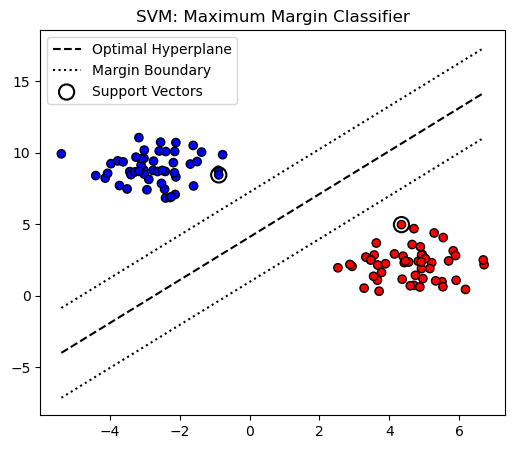

In [7]:
# 4) Visualization

plt.figure(figsize=(6, 5))

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolor="k")

# Plot optimal hyperplane
plt.plot(x_vals, y_vals, "k--", label="Optimal Hyperplane")

# Plot margins
plt.plot(x_vals, y_margin_pos, "k:", label="Margin Boundary")

plt.plot(x_vals, y_margin_neg, "k:")

# Highlight support vectors
plt.scatter(
    svm.support_vectors_[:, 0],
    svm.support_vectors_[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    linewidths=1.5,
    label="Support Vectors"
)

plt.title("SVM: Maximum Margin Classifier")
plt.legend()
plt.show()

In [8]:
# 5) Print key quantities (for explanation)

print("Weight vector w:", w)
print("Bias b:", b)

print("Margin (1/||w||):", margin)

print("Number of support vectors:", len(svm.support_vectors_))

Weight vector w: [ 0.26506647 -0.17623745]
Bias b: 0.7223721957923663
Margin (1/||w||): 3.141612960382368
Number of support vectors: 2
